In [270]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [271]:
%autoreload 2
from utils import (
    select_users_by_period,
    create_hourly_user_dataset,
)
from visualization_utils import (
    plot_user_metrics,
    plot_market_features,
)


In [272]:
import pandas as pd
import numpy as np
import json
pd.set_option('display.max_columns', 500)

# MARKET = "eth_cbbtc_usdc"
MARKET = "base_cbbtc_usdc_full"
EVENTS_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched"
HOURLY_MARKET_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data"
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(f"{EVENTS_PATH}/{MARKET}.csv")
market_df = pd.read_csv(f"{HOURLY_MARKET_PATH}/{MARKET}.csv")

df.head(2)

,hash,type,timestamp,user_address,assets,assets_usd,liquidated_assets,liquidated_assets_usd,market,datetime,market_address,total_supply_before,total_borrow_before,total_supply_after,total_borrow_after,utilization_before,utilization_after,tx_actions,borrow_rate_before,supply_rate_before,borrow_rate_after,supply_rate_after,collateral_price,loan_asset_price,collateral_before,collateral_value_before,debt_before,supply_before,ltv_before,collateral_after,collateral_value_after,debt_after,supply_after,ltv_after,health_factor_before,health_factor_after,event_type,vault_flg,volatility_6h,drawdown_6h,trend_6h,volatility_24h,drawdown_24h,trend_24h,event_sequence_type,collateral_asset_symbol,loan_asset_symbol
0,0x4b95f45c3afdbdb97aca807ddc82d4d2b7cd2c09801b...,MarketSupply,1726217265,0xf8b9D83574574A345c32905a2A62D1d84650A0Ae,1000000,1.001,0,0.0,base_cbbtc_usdc,2024-09-13 08:47:45,0x9103c3b4e834476c9a62ea009ba2c884ee42e94e6e31...,0.0,0.0,1.000000,0.0,0.0,0.000000,1,0.002968,0.0,0.002968,0.000000,58132.0,1,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0,1.0,0.000000,0.0,0.000000,loan_position_supply,False,0.001659,-0.002464,-0.00422,0.003227,-0.002464,-0.000207,loan_position_supply,cbBTC,USDC
1,0xbc8e2030283aef18ec38474c5a6f62dbb20bc9d18688...,MarketBorrow,1726217705,0xf8b9D83574574A345c32905a2A62D1d84650A0Ae,1000000,1.001,0,0.0,base_cbbtc_usdc,2024-09-13 08:55:05,0x9103c3b4e834476c9a62ea009ba2c884ee42e94e6e31...,1.0,0.0,1.016478,1.0,0.0,0.983789,3,0.002968,0.0,0.041709,0.041041,58132.0,1,0.0,0.0,0.0,1.0,0.0,0.0001,5.8132,1.0,1.0,0.172022,0.0,4.999352,position_open,False,0.001659,-0.002464,-0.00422,0.003227,-0.002464,-0.000207,position_open,cbBTC,USDC


In [273]:
df["utilization_after"].quantile(0.98)


0.9042481725864738

In [274]:
# market_df["borrow_rate_rolling"].plot()

plot_market_features(
    market_df,
    ["borrow_rate", "utilization"]
)

In [293]:
import pandas as pd

import numpy as np
import pandas as pd


import numpy as np
import pandas as pd

def detect_market_spikes(df, start_date, lookback_hours=6, metrics_config=None, actions_limit=10, max_recovery_events=50):
    """
    Detect spikes in specified market metrics and return enriched spike information.
    
    Returns list of dicts with keys:
        trigger_datetime, recovery_datetime (if recovered), recovery_time_seconds,
        spike_magnitudes (dict), trigger_event_types (comma-separated),
        market_state (dict with total_borrow, total_supply, collateral_price, loan_asset_price,
                     debt_before, supply_before, utilization_before),
        actions_df (DataFrame of actions during spike), spike_duration_events (int).
    """
    if metrics_config is None:
        metrics_config = {
            'utilization_after': {'spike_threshold': 0.05, 'high_threshold': 0.9, 'tolerance': 0.02}
        }
    
    if 'datetime' not in df.columns and 'timestamp' in df.columns:
        df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
    df = df.sort_values('timestamp').copy()
    
    start_ts = pd.Timestamp(start_date).timestamp()
    df = df[df['timestamp'] >= start_ts].reset_index(drop=True)
    if df.empty:
        return []
    
    timestamps = df['timestamp'].values
    lookback_sec = lookback_hours * 3600
    past_indices = np.searchsorted(timestamps, timestamps - lookback_sec, side='right') - 1
    
    metric_arrays = {}
    for metric in metrics_config.keys():
        if metric in df.columns:
            metric_arrays[metric] = df[metric].values
        else:
            raise KeyError(f"Metric '{metric}' not found in DataFrame columns")
    
    spikes = []
    i = 0
    n = len(df)
    while i < n and len(spikes) < actions_limit:
        past_idx = past_indices[i]
        if past_idx >= 0:
            triggered_metrics = {}
            baseline_vals = {}
            for metric, cfg in metrics_config.items():
                current_val = metric_arrays[metric][i]
                past_val = metric_arrays[metric][past_idx]
                delta = current_val - past_val
                if delta > cfg['spike_threshold'] and current_val > cfg['high_threshold'] and past_val < cfg['high_threshold']:
                    triggered_metrics[metric] = delta
                    baseline_vals[metric] = past_val
            
            if triggered_metrics:
                trigger_idx = i
                trigger_row = df.iloc[trigger_idx]
                trigger_tx_hash = trigger_row['hash']
                # Get all rows with same hash (same transaction) at trigger time
                trigger_tx_rows = df[(df['timestamp'] == trigger_row['timestamp']) & (df['hash'] == trigger_tx_hash)]
                trigger_event_types = ','.join(sorted(trigger_tx_rows['type'].unique()))
                
                # Market state at trigger (use before values or after? using before for consistency)
                market_state = {
                    'total_borrow': trigger_row.get('total_borrow_before', np.nan),
                    'total_supply': trigger_row.get('total_supply_before', np.nan),
                    'collateral_price': trigger_row.get('collateral_price', np.nan),
                    'loan_asset_price': trigger_row.get('loan_asset_price', np.nan),
                    'debt_before': trigger_row.get('debt_before', np.nan),
                    'supply_before': trigger_row.get('supply_before', np.nan),
                    'utilization_before': trigger_row.get('utilization_before', np.nan)
                }
                
                # Find recovery
                recovery_idx = None
                recovery_time = None
                for offset in range(max_recovery_events):
                    j = trigger_idx + offset
                    if j >= n:
                        break
                    all_recovered = True
                    for metric, cfg in metrics_config.items():
                        if metric in triggered_metrics:
                            current = metric_arrays[metric][j]
                            baseline = baseline_vals[metric]
                            # Recovery if: back to baseline (± tolerance) OR below high_threshold - tolerance
                            high_thresh = cfg['high_threshold']
                            low_threshold = cfg.get('low_threshold', None)
                            recovered = (abs(current - baseline) <= cfg['tolerance']) or (low_threshold is not None and current < low_threshold)
                            if not recovered:
                                all_recovered = False
                                break
                    if all_recovered:
                        recovery_idx = j
                        recovery_time = df.iloc[recovery_idx]['timestamp'] - df.iloc[trigger_idx]['timestamp']
                        break
                
                if recovery_idx is not None:
                    spike_df = df.iloc[trigger_idx:recovery_idx+1].copy()
                    next_i = recovery_idx + 1
                else:
                    # No recovery within limit, take up to max_recovery_events rows
                    end_idx = min(trigger_idx + max_recovery_events, n)
                    spike_df = df.iloc[trigger_idx:end_idx].copy()
                    recovery_time = None
                    next_i = end_idx
                
                spikes.append({
                    'trigger_datetime': trigger_row['datetime'],
                    'recovery_datetime': df.iloc[recovery_idx]['datetime'] if recovery_idx is not None else None,
                    'recovery_time_seconds': recovery_time,
                    'spike_magnitudes': triggered_metrics,
                    'trigger_event_types': trigger_event_types,
                    'market_state': market_state,
                    'actions_df': spike_df,
                    'spike_duration_events': len(spike_df)
                })
                i = next_i
                continue
        i += 1
    
    return spikes


In [294]:
metrics_config = {
    'utilization_after': {
        'spike_threshold': 0.05,    # 5% increase
        'high_threshold': 0.9,      # must exceed 90% utilization
        'low_threshold': 0.895,
        'tolerance': 0.01           # recovery within 2% of baseline
    },
}

# Detect spikes
spikes = detect_market_spikes(
    df=df,
    start_date='2025-03-01',
    lookback_hours=1,
    metrics_config=metrics_config,
    actions_limit=1000
)
len(spikes)

46

In [292]:
spikes[0]['actions_df']

,hash,type,timestamp,user_address,assets,assets_usd,liquidated_assets,liquidated_assets_usd,market,datetime,market_address,total_supply_before,total_borrow_before,total_supply_after,total_borrow_after,utilization_before,utilization_after,tx_actions,borrow_rate_before,supply_rate_before,borrow_rate_after,supply_rate_after,collateral_price,loan_asset_price,collateral_before,collateral_value_before,debt_before,supply_before,ltv_before,collateral_after,collateral_value_after,debt_after,supply_after,ltv_after,health_factor_before,health_factor_after,event_type,vault_flg,volatility_6h,drawdown_6h,trend_6h,volatility_24h,drawdown_24h,trend_24h,event_sequence_type,collateral_asset_symbol,loan_asset_symbol
47864,0x5966723dfd9afba99b18e730dafb4b6effabce733eab...,MarketWithdraw,1742536473,0xc1256Ae5FF1cf2719D4937adb3bbCCab2E00A2Ca,2800000000000,2.799700e+06,0,0.0,base_cbbtc_usdc,2025-03-21 05:54:33,0x9103c3b4e834476c9a62ea009ba2c884ee42e94e6e31...,1.491034e+08,1.284657e+08,1.435035e+08,1.284657e+08,0.861588,0.895210,2,0.049647,0.042776,0.051084,0.045732,84346.0,1,0.000000,0.000000,0.000000,2.853840e+07,0.000000,0.000000,0.000000,0.000000,2.293840e+07,0.000000,0.000000,0.000000,loan_position_withdraw,True,0.002554,-0.00612,0.006158,0.005220,-0.010952,-0.013462,loan_position_withdraw,cbBTC,USDC
47865,0x5966723dfd9afba99b18e730dafb4b6effabce733eab...,MarketWithdraw,1742536473,0xc1256Ae5FF1cf2719D4937adb3bbCCab2E00A2Ca,2800000000000,2.799700e+06,0,0.0,base_cbbtc_usdc,2025-03-21 05:54:33,0x9103c3b4e834476c9a62ea009ba2c884ee42e94e6e31...,1.491034e+08,1.284657e+08,1.435035e+08,1.284657e+08,0.861588,0.895210,2,0.049647,0.042776,0.051084,0.045732,84346.0,1,0.000000,0.000000,0.000000,2.853840e+07,0.000000,0.000000,0.000000,0.000000,2.293840e+07,0.000000,0.000000,0.000000,loan_position_withdraw,True,0.002554,-0.00612,0.006158,0.005220,-0.010952,-0.013462,loan_position_withdraw,cbBTC,USDC
47866,0x20a471ac1f3226a8e67a980aeaaaf4d7204b09ab8d04...,MarketSupplyCollateral,1742536607,0xfF6acfD7C8E72f17FECA478ddA44324C76d2e6eB,7113505,6.020799e+03,0,0.0,base_cbbtc_usdc,2025-03-21 05:56:47,0x9103c3b4e834476c9a62ea009ba2c884ee42e94e6e31...,1.435035e+08,1.284657e+08,1.435035e+08,1.284717e+08,0.895210,0.895252,4,0.051084,0.045732,0.051086,0.045736,84346.0,1,0.500171,42187.390271,21100.000000,0.000000e+00,0.500149,0.642441,54187.304126,27100.000000,0.000000e+00,0.500117,1.719486,1.719597,borrow_more_w_collateral,False,0.002554,-0.00612,0.006158,0.005220,-0.010952,-0.013462,borrow_more_w_collateral,cbBTC,USDC
47867,0x20a471ac1f3226a8e67a980aeaaaf4d7204b09ab8d04...,MarketBorrow,1742536607,0xfF6acfD7C8E72f17FECA478ddA44324C76d2e6eB,3000000000,2.999679e+03,0,0.0,base_cbbtc_usdc,2025-03-21 05:56:47,0x9103c3b4e834476c9a62ea009ba2c884ee42e94e6e31...,1.435035e+08,1.284657e+08,1.435035e+08,1.284717e+08,0.895210,0.895252,4,0.051084,0.045732,0.051086,0.045736,84346.0,1,0.500171,42187.390271,21100.000000,0.000000e+00,0.500149,0.642441,54187.304126,27100.000000,0.000000e+00,0.500117,1.719486,1.719597,borrow_more_w_collateral,False,0.002554,-0.00612,0.006158,0.005220,-0.010952,-0.013462,borrow_more_w_collateral,cbBTC,USDC
47868,0x20a471ac1f3226a8e67a980aeaaaf4d7204b09ab8d04...,MarketSupplyCollateral,1742536607,0xfF6acfD7C8E72f17FECA478ddA44324C76d2e6eB,7113505,6.020799e+03,0,0.0,base_cbbtc_usdc,2025-03-21 05:56:47,0x9103c3b4e834476c9a62ea009ba2c884ee42e94e6e31...,1.435035e+08,1.284657e+08,1.435035e+08,1.284717e+08,0.895210,0.895252,4,0.051084,0.045732,0.051086,0.045736,84346.0,1,0.500171,42187.390271,21100.000000,0.000000e+00,0.500149,0.642441,54187.304126,27100.000000,0.000000e+00,0.500117,1.719486,1.719597,borrow_more_w_collateral,False,0.002554,-0.00612,0.006158,0.005220,-0.010952,-0.013462,borrow_more_w_collateral,cbBTC,USDC
47869,0x20a471ac1f3226a8e67a980aeaaaf4d7204b09ab8d04...,MarketBorrow,1742536607,0xfF6acfD7C8E72f17FECA478ddA44324C76d2e6eB,3000000000,2.999679e+03,0,0.0,base_cbbtc_usdc,2025-03-21 05:56:47,0x9103c3b4e834476c9a62ea009ba2c884ee42e94e6e31...,1.435035e+08

In [278]:
for i in spikes:
    eps=0.001
    actions_df = i["actions_df"]
    actions_df = actions_df[np.abs(actions_df["borrow_rate_after"] - actions_df["borrow_rate_before"]) > eps]
    print(i["trigger_datetime"], i["actions_df"]["datetime"].max(), i["actions_df"].shape[0], "->", actions_df.shape[0])
    print(actions_df["type"].value_counts())

2025-03-21 05:54:33 2025-03-21 06:12:51 37 -> 3
type
MarketWithdraw    3
Name: count, dtype: int64
2025-04-01 11:52:51 2025-04-01 11:53:11 2 -> 0
Series([], Name: count, dtype: int64)
2025-04-01 11:54:47 2025-04-01 11:56:57 2 -> 0
Series([], Name: count, dtype: int64)
2025-04-01 11:57:39 2025-04-01 11:58:35 2 -> 0
Series([], Name: count, dtype: int64)
2025-04-01 11:59:39 2025-04-01 11:59:45 2 -> 0
Series([], Name: count, dtype: int64)
2025-04-01 12:00:55 2025-04-01 12:12:45 21 -> 0
Series([], Name: count, dtype: int64)
2025-04-01 12:13:11 2025-04-01 12:17:31 4 -> 0
Series([], Name: count, dtype: int64)
2025-04-01 12:23:21 2025-04-01 12:35:31 36 -> 0
Series([], Name: count, dtype: int64)
2025-04-06 23:22:51 2025-04-06 23:33:15 50 -> 0
Series([], Name: count, dtype: int64)
2025-05-01 19:24:17 2025-05-01 19:37:25 50 -> 1
type
MarketWithdraw    1
Name: count, dtype: int64
2025-05-01 19:37:25 2025-05-01 19:55:41 50 -> 6
type
MarketSupply      4
MarketWithdraw    2
Name: count, dtype: int64


In [279]:
spikes[0].keys()
spikes[0]["trigger_event_types"]

'MarketWithdraw'

In [280]:
spikes[0]["actions_df"][[
    "datetime",
    "type",
    "utilization_before",
    "utilization_after",
    "user_address"
]]

,datetime,type,utilization_before,utilization_after,user_address
47864,2025-03-21 05:54:33,MarketWithdraw,0.861588,0.895210,0xc1256Ae5FF1cf2719D4937adb3bbCCab2E00A2Ca
47865,2025-03-21 05:54:33,MarketWithdraw,0.861588,0.895210,0xc1256Ae5FF1cf2719D4937adb3bbCCab2E00A2Ca
47866,2025-03-21 05:56:47,MarketSupplyCollateral,0.895210,0.895252,0xfF6acfD7C8E72f17FECA478ddA44324C76d2e6eB
47867,2025-03-21 05:56:47,MarketBorrow,0.895210,0.895252,0xfF6acfD7C8E72f17FECA478ddA44324C76d2e6eB
47868,2025-03-21 05:56:47,MarketSupplyCollateral,0.895210,0.895252,0xfF6acfD7C8E72f17FECA478ddA44324C76d2e6eB
47869,2025-03-21 05:56:47,MarketBorrow,0.895210,0.895252,0xfF6acfD7C8E72f17FECA478ddA44324C76d2e6eB
47870,2025-03-21 05:58:37,MarketRepay,0.895252,0.895249,0xDA811bE66ed23A32BB9058E19d9Cd4Edee39F3C1
47871,2025-03-21 05:58:37,MarketWithdrawCollateral,0.895252,0.895249,0xDA811bE66ed23A32BB9058E19d9Cd4Edee39F3C1
47872,2025-03-21 05:58:37,MarketWithdrawCollateral,0.895252,0.895249,0xDA811bE66ed23A32BB9058E19d9Cd4Edee39F3C1
47873,2025-03-21 05:58:37,MarketRepay,0.895252,0.895249,0xDA811bE66ed23A32BB9058E19d9Cd4Edee39F3C1


**Spikes actions analisys**

In [281]:
def analyze_action_impact(spikes, delta_threshold=-0.01):
    """
    For each action in each spike (excluding the trigger), compute delta_util and volume.
    Returns:
      - all_actions: DataFrame of every action
      - summary: aggregated by action type (overall)
      - spike_summary: per‑spike occurrence and impact of each action type
    """
    action_records = []
    spike_records = []
    
    for spike in spikes:
        df_actions = spike['actions_df'].copy().dropna()
        if df_actions.empty:
            continue
        
        trigger_ts = spike['trigger_datetime']
        df_actions = df_actions[df_actions['datetime'] > trigger_ts]
        if df_actions.empty:
            continue
        
        spike_id = spike['trigger_datetime']
        
        # Per‑action calculations
        df_actions['delta_util'] = df_actions['utilization_after'] - df_actions['utilization_before']
        if 'assets_usd' in df_actions.columns:
            df_actions['volume_usd'] = df_actions['assets_usd'].abs()
        elif 'assets' in df_actions.columns and 'collateral_price' in df_actions.columns:
            df_actions['volume_usd'] = df_actions['assets'].abs() * df_actions['collateral_price']
        else:
            df_actions['volume_usd'] = 1.0
        
        # Store for per‑action summary
        action_records.append(df_actions[['type', 'delta_util', 'volume_usd', 'timestamp']])
        
        # Per‑spike summary: which action types occurred and had significant effect
        action_types = df_actions['type'].unique()
        for atype in action_types:
            type_actions = df_actions[df_actions['type'] == atype]
            n_actions = len(type_actions)
            total_volume = type_actions['volume_usd'].sum()
            has_significant = (type_actions['delta_util'] < delta_threshold).any()
            # Also compute the best (most negative) delta achieved by this action type in this spike
            best_delta = type_actions['delta_util'].min()
            
            spike_records.append({
                'spike_id': spike_id,
                'action_type': atype,
                'occurred': True,
                'n_actions': n_actions,
                'total_volume_usd': total_volume,
                'has_significant_reduction': has_significant,
                'best_delta': best_delta
            })
    
    if not action_records:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    
    all_actions = pd.concat(action_records, ignore_index=True)
    all_actions = all_actions[all_actions["type"].isin([
        "MarketSupply",
        "MarketRepay",
        "MarketLiquidation",
        "MarketBorrow",
        "MarketWithdraw",
    ])]

    
    # Overall summary (same as before)
    summary = all_actions.groupby('type').agg(
        count=('delta_util', 'size'),
        mean_delta=('delta_util', 'mean'),
        median_delta=('delta_util', 'median'),
        total_volume_usd=('volume_usd', 'sum'),
        weighted_mean_delta=('delta_util', lambda x: np.average(x, weights=all_actions.loc[x.index, 'volume_usd']))
    ).round(4)
    
    # Per‑spike summary aggregated across spikes
    spike_df = pd.DataFrame(spike_records)
    if not spike_df.empty:
        spike_summary = spike_df.groupby('action_type').agg(
            spikes_present=('occurred', 'sum'),
            spikes_present_pct=('occurred', lambda x: x.sum() / len(spikes) * 100),
            total_actions=('n_actions', 'sum'),
            avg_actions_per_spike=('n_actions', 'mean'),
            avg_volume_per_spike=('total_volume_usd', 'mean'),
            spikes_with_significant_reduction=('has_significant_reduction', 'sum'),
            pct_spikes_with_significant=('has_significant_reduction', lambda x: x.sum() / len(spikes) * 100),
            avg_best_delta=('best_delta', 'mean')
        ).round(4)
    else:
        spike_summary = pd.DataFrame()
    
    return all_actions, summary, spike_summary


analyze_action_impact(spikes)[1]





,count,mean_delta,median_delta,total_volume_usd,weighted_mean_delta
type,,,,,
MarketBorrow,218,-0.0000,0.0,2.272784e+06,0.0003
MarketLiquidation,6,-0.0000,-0.0,9.339368e+03,-0.0000
MarketRepay,162,-0.0000,-0.0,1.304093e+06,-0.0002
MarketSupply,1117,-0.0023,-0.0,1.382125e+09,-0.0496
MarketWithdraw,301,0.0009,0.0,1.922055e+08,0.0225


In [282]:
for i in spikes[:1550]:
    df_actions = i['actions_df'].copy()
    if df_actions.empty:
        continue
    
    trigger_ts = i['trigger_datetime']
    df_actions = df_actions[df_actions['datetime'] > trigger_ts]
    if df_actions.empty:
        continue
    if 'MarketRepay' in df_actions["type"].unique():
        display(df_actions[df_actions['type'] == 'MarketRepay'][[
            "datetime",
            "type",
            "utilization_before",
            "utilization_after",
            "borrow_rate_after",
            "user_address"
        ]])
        print("=" * 250)


,datetime,type,utilization_before,utilization_after,borrow_rate_after,user_address
47870,2025-03-21 05:58:37,MarketRepay,0.895252,0.895249,0.051086,0xDA811bE66ed23A32BB9058E19d9Cd4Edee39F3C1
47873,2025-03-21 05:58:37,MarketRepay,0.895252,0.895249,0.051086,0xDA811bE66ed23A32BB9058E19d9Cd4Edee39F3C1
47874,2025-03-21 05:59:13,MarketRepay,0.895249,0.895249,0.051086,0xfF6acfD7C8E72f17FECA478ddA44324C76d2e6eB
47875,2025-03-21 05:59:13,MarketRepay,0.895249,0.895249,0.051086,0xfF6acfD7C8E72f17FECA478ddA44324C76d2e6eB
47897,2025-03-21 06:08:09,MarketRepay,0.889411,0.889406,0.050835,0x5C9a029eaEeeD43DF73c01fb00cF1a7D3493080E
47898,2025-03-21 06:08:09,MarketRepay,0.889411,0.889406,0.050835,0x5C9a029eaEeeD43DF73c01fb00cF1a7D3493080E


,datetime,type,utilization_before,utilization_after,borrow_rate_after,user_address
80217,2025-04-01 12:05:45,MarketRepay,0.890363,0.890362,0.045094,0x8AB0E226DbF76702cAcc37f3DcF5AAB8C04ed435


,datetime,type,utilization_before,utilization_after,borrow_rate_after,user_address
80255,2025-04-01 12:27:45,MarketRepay,0.888585,0.888584,0.045026,0x4bBeDD68cFddF3afCdD96b5799CE46916B917aAD


,datetime,type,utilization_before,utilization_after,borrow_rate_after,user_address
101868,2025-04-06 23:25:23,MarketRepay,0.891354,0.891354,0.047828,0x46271115F374E02b5afe357C8E8Dad474c8DE1cF
101869,2025-04-06 23:25:27,MarketRepay,0.891354,0.891237,0.047823,0x02BCeaeD9F8d90E3a95745E514D23629Dc123484
101877,2025-04-06 23:28:21,MarketRepay,0.891250,0.891220,0.047822,0x199f900359E7b376b60F9196ab801EFBDaD4B1E4
101880,2025-04-06 23:28:39,MarketRepay,0.891282,0.890717,0.047802,0x5c70B3F22595CAf8314F77DAbC628363AAEe18aD
101885,2025-04-06 23:29:37,MarketRepay,0.890731,0.890730,0.047803,0x841aD4368C0d29eDB8f5E6255815f3EB82aBab6F
101890,2025-04-06 23:30:05,MarketRepay,0.890785,0.890782,0.047805,0x8c321aD515175068b1D53F75b24FF321Bd90d82E
101892,2025-04-06 23:30:29,MarketRepay,0.890794,0.890755,0.047804,0x121622F07CB70a3F08f0D7c764b01C50cdfacFA4
101894,2025-04-06 23:30:51,MarketRepay,0.890755,0.890190,0.047781,0x5c70B3F22595CAf8314F77DAbC628363AAEe18aD
101903,2025-04-06 23:32:33,MarketRepay,0.887149,0.886586,0.047636,0x5c70B3F22595CAf8314F77DAbC628363AAEe18aD
101905,2025-04-06 23:33:03,MarketRepay,0.886134,0.886126,0.047618,0x348cb48D444E466F374934733736033bFDaAca04


,datetime,type,utilization_before,utilization_after,borrow_rate_after,user_address
184345,2025-05-01 19:29:03,MarketRepay,0.928525,0.928525,0.094034,0xADf1C5E5c22937095f36c8b1041006c67088f5c4


...

,datetime,type,utilization_before,utilization_after,borrow_rate_after,user_address
1054128,2025-10-05 05:05:05,MarketRepay,0.947293,0.947292,0.172777,0x0c5F335126Ba43e3298007A0208eCF1a2fb01394
1054141,2025-10-05 05:06:11,MarketRepay,0.947280,0.947269,0.172727,0x869fB07839b0632A707aFC677ca56FC76db9c5b8
1054155,2025-10-05 05:07:27,MarketRepay,0.947275,0.947275,0.172739,0x3A92bBB070599eE45Cd7037DD1B73767E8F0499B


,datetime,type,utilization_before,utilization_after,borrow_rate_after,user_address
1054185,2025-10-05 05:09:27,MarketRepay,0.941777,0.941777,0.160957,0xFEc52d792e2fA7cD5dAFD58cfF81F0dBbBbE7B0e


,datetime,type,utilization_before,utilization_after,borrow_rate_after,user_address
1054219,2025-10-05 05:12:25,MarketRepay,0.941470,0.941469,0.160297,0xE2396eD794cb836f68b3C2c8F7CAa9322c4d4924
1054221,2025-10-05 05:12:45,MarketRepay,0.941450,0.941449,0.160256,0xFEc52d792e2fA7cD5dAFD58cfF81F0dBbBbE7B0e
1054252,2025-10-05 05:16:33,MarketRepay,0.941445,0.941445,0.160246,0xFEc52d792e2fA7cD5dAFD58cfF81F0dBbBbE7B0e
1054255,2025-10-05 05:16:47,MarketRepay,0.941448,0.941447,0.160252,0x0b9BAadac8Ff55524b53Df52d28f8Cb7C00B8338


,datetime,type,utilization_before,utilization_after,borrow_rate_after,user_address
1054269,2025-10-05 05:18:29,MarketRepay,0.941424,0.941387,0.160122,0x32B66388862611463344BDA12fbA0c825AB8ad5F


,datetime,type,utilization_before,utilization_after,borrow_rate_after,user_address
1054343,2025-10-05 05:24:31,MarketRepay,0.941592,0.941592,0.160562,0xb47e2B29123a06B56aD0d2A3cb792b7B9a529f5c


**Modeling -- spike duration**

In [283]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import statsmodels.api as sm
from sklearn.feature_selection import f_regression



def extract_spike_features(spikes):
    features_list = []
    for spike in spikes:
        df_actions = spike['actions_df']
        valid_actions = ['MarketRepay', 'MarketSupply', 'MarketWithdraw']
        df_actions = df_actions[df_actions['type'].isin(valid_actions)]
        if df_actions.empty:
            continue
        
        spike_mag = spike['spike_magnitudes'].get('utilization_after', 0)
        market_state = spike['market_state']
        
        # Use raw counts instead of proportions
        action_counts = df_actions['type'].value_counts().to_dict()
        # Drop one category to avoid perfect multicollinearity (e.g., drop MarketWithdraw)
        drop_col = 'MarketWithdraw'
        norm_counts = {}
        for k, v in action_counts.items():
            if k != drop_col:
                norm_counts[f'count_{k}'] = v
        
        # First action after trigger (use raw count, not one-hot)
        if len(df_actions) > 1:
            first_action = df_actions.iloc[1]['type']
        else:
            first_action = 'none'
        
        n_unique_users = df_actions['user_address'].nunique()
        total_actions = len(df_actions)
        recovery_time = spike.get('recovery_time_seconds', np.nan)
        if pd.isna(recovery_time):
            continue
        
        features = {
            'spike_magnitude': spike_mag,
            'collateral_price': market_state.get('collateral_price', 0),
            'loan_asset_price': market_state.get('loan_asset_price', 0),
            'utilization_before': market_state.get('utilization_before', 0),
            'first_action_MarketSupply': 1 if first_action == 'MarketSupply' else 0,
            'first_action_MarketRepay': 1 if first_action == 'MarketRepay' else 0,
            **norm_counts,
            'recovery_time_seconds': recovery_time
        }
        features_list.append(features)
    
    df_features = pd.DataFrame(features_list).fillna(0)
    # Drop any remaining columns that are constant or nearly constant
    constant_cols = [col for col in df_features.columns if df_features[col].nunique() <= 1]
    df_features = df_features.drop(columns=constant_cols)
    return df_features

def train_recovery_model(features_df, target_col='recovery_time_seconds', test_size=0.2, use_ridge=True):
    """
    Train a linear regression model to predict recovery time with detailed feature analysis.
    Returns model, scaler, evaluation metrics, and feature importance DataFrame.
    """
    X = features_df.drop(columns=[target_col])
    y = np.log1p(features_df[target_col])
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model with regularization to handle multicollinearity
    if use_ridge:
        model = Ridge(alpha=1.0)
        model.fit(X_train_scaled, y_train)
    else:
        model = LinearRegression()
        model.fit(X_train_scaled, y_train)
    
    # Predict and evaluate
    y_pred = model.predict(X_test_scaled)
    y_pred_exp = np.expm1(y_pred)
    y_test_exp = np.expm1(y_test)
    
    print("=" * 60)
    print("MODEL PERFORMANCE")
    print("=" * 60)
    print(f"R² score: {r2_score(y_test, y_pred):.3f}")
    print(f"RMSE (seconds): {np.sqrt(mean_squared_error(y_test_exp, y_pred_exp)):.1f}")
    print(f"MAE (seconds): {mean_absolute_error(y_test_exp, y_pred_exp):.1f}")
    
    # Feature importance using statsmodels for p-values
    X_train_sm = sm.add_constant(X_train_scaled)
    try:
        sm_model = sm.OLS(y_train, X_train_sm).fit()
        p_values = sm_model.pvalues[1:]  # exclude constant
    except:
        p_values = [np.nan] * len(X.columns)
    
    # Create feature importance DataFrame
    coef_df = pd.DataFrame({
        'feature': X.columns,
        'coefficient': model.coef_,
        'abs_coefficient': np.abs(model.coef_),
        'p_value': p_values,
        'significant': p_values < 0.05 if not np.isnan(p_values).any() else False
    })
    
    # For Ridge, we don't have p-values, so we use coefficient magnitude as importance
    if use_ridge:
        coef_df['importance'] = np.abs(model.coef_)
        coef_df = coef_df.sort_values('importance', ascending=False)
        print("\n" + "=" * 60)
        print("TOP 10 FEATURES (Ridge Regression - by coefficient magnitude)")
        print("=" * 60)
    else:
        coef_df = coef_df.sort_values('abs_coefficient', ascending=False)
        print("\n" + "=" * 60)
        print("TOP 10 FEATURES (Linear Regression - by coefficient magnitude)")
        print("=" * 60)
        print("Positive coefficient = slower recovery | Negative = faster recovery")
        print("p < 0.05 indicates statistical significance")
    
    print(coef_df.head(10).to_string(index=False))
    
    # Also show F-regression scores for feature ranking
    f_scores, f_pvalues = f_regression(X_train_scaled, y_train)
    f_df = pd.DataFrame({
        'feature': X.columns,
        'f_score': f_scores,
        'f_pvalue': f_pvalues
    }).sort_values('f_score', ascending=False)
    
    print("\n" + "=" * 60)
    print("TOP 10 FEATURES (F-regression - univariate predictive power)")
    print("=" * 60)
    print(f_df.head(10).to_string(index=False))
    
    return model, scaler, coef_df


spikes_features_df = extract_spike_features(spikes)
spikes_features_df
train_recovery_model(
    spikes_features_df
)

MODEL PERFORMANCE
R² score: 0.561
RMSE (seconds): 242.6
MAE (seconds): 166.3

TOP 10 FEATURES (Ridge Regression - by coefficient magnitude)
                  feature  coefficient  abs_coefficient  p_value  significant  importance
        count_MarketRepay     0.971902         0.971902 0.002524         True    0.971902
       count_MarketSupply     0.671868         0.671868 0.021017         True    0.671868
       utilization_before    -0.548477         0.548477 0.034476         True    0.548477
first_action_MarketSupply     0.508337         0.508337 0.063217        False    0.508337
 first_action_MarketRepay     0.377893         0.377893 0.133056        False    0.377893
          spike_magnitude     0.242428         0.242428 0.484808        False    0.242428
         collateral_price     0.188637         0.188637 0.541707        False    0.188637

TOP 10 FEATURES (F-regression - univariate predictive power)
                  feature   f_score  f_pvalue
        count_MarketRepay 15.539

(Ridge(),
 StandardScaler(),
                       feature  coefficient  abs_coefficient   p_value  \
 x7          count_MarketRepay     0.971902         0.971902  0.002524   
 x6         count_MarketSupply     0.671868         0.671868  0.021017   
 x3         utilization_before    -0.548477         0.548477  0.034476   
 x4  first_action_MarketSupply     0.508337         0.508337  0.063217   
 x5   first_action_MarketRepay     0.377893         0.377893  0.133056   
 x1            spike_magnitude     0.242428         0.242428  0.484808   
 x2           collateral_price     0.188637         0.188637  0.541707   
 
     significant  importance  
 x7         True    0.971902  
 x6         True    0.671868  
 x3         True    0.548477  
 x4        False    0.508337  
 x5        False    0.377893  
 x1        False    0.242428  
 x2        False    0.188637  )

**Analyzing users with huge volume**

In [284]:
user_debt = df[df["user_address"].isin( df[df["type"] == 'MarketBorrow']["user_address"].unique() )].groupby("user_address")["debt_after"].max()
user_debt.describe()

small_users = user_debt[user_debt<np.quantile(user_debt, 0.9)].index
large_users = user_debt[user_debt>=np.quantile(user_debt, 0.9)].index
user_debt[large_users].describe()

count    2.911000e+03
mean     3.964868e+05
std      1.156839e+06
min      1.000000e+05
25%      1.349686e+05
50%      2.080136e+05
75%      4.000000e+05
max      3.840002e+07
Name: debt_after, dtype: float64

In [285]:
small_df = df[(df["datetime"] >= "2025-03-01") & df["user_address"].isin(small_users)]
(small_df["utilization_after"] - small_df["utilization_before"]).sort_values(ascending=False)

232280    0.012684
229835    0.003280
270349    0.001472
255672    0.001028
158650    0.001012
            ...   
195610   -0.030488
195611   -0.030488
208128   -0.030711
208129   -0.030711
190900   -0.031047
Length: 293852, dtype: float64

In [286]:
# small_df.iloc[3840]
small_df[small_df["user_address"] == "0xf37414de43b7D79859d30ec39C6bC0B3c7672135"][[
    "datetime",
    "type",
    "debt_before",
    "debt_after",
    "ltv_after",
    "event_type",
]]

,datetime,type,debt_before,debt_after,ltv_after,event_type


**All markets analisys**

In [302]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

LARGE_MARKET_THRESHOLD = 50_000

def process_all_markets(events_dir, hourly_dir, metrics_config=None, 
                        spike_params=None, action_threshold=-0.01, 
                        early_market_only=False,
                        output_md_path="/Users/yegortrussov/Documents/ml/lending_protocols/experiments_logs/spikes_events/utilization_stabilize_report.md"):
    """
    Process all eligible markets, detect spikes, analyze actions, and produce a markdown report.
    """
    output_txt_path = output_md_path.replace('.md', '_detailed.md')
    if metrics_config is None:
        metrics_config = {
            'utilization_after': {
                'spike_threshold': 0.05,    # 5% increase
                'high_threshold': 0.9,      # must exceed 90% utilization
                'low_threshold': 0.895,
                'tolerance': 0.01    
            }
        }
    if spike_params is None:
        spike_params = {
            'lookback_hours': 1,
            'actions_limit': 300,
            'max_recovery_events': 100
        }
    
    # Ensure output directory exists
    os.makedirs(os.path.dirname(output_md_path), exist_ok=True)
    
    all_markets_data = []

    with open(output_txt_path, 'w') as txt_f:
        txt_f.write("# Detailed Spike Analysis\n\n")
    
    for fname in os.listdir(events_dir):
        if not fname.endswith('.csv'):
            continue
        market_name = fname[:-4]
        if 'PT-' in market_name:
            # print(f"Skipping PT- market: {market_name}")
            # continue
            pass
        
        events_path = os.path.join(events_dir, fname)
        
        try:
            df = pd.read_csv(events_path)
            df = df.sort_values('timestamp')
            if not early_market_only:
                cut_idx = int(len(df) * 0.2) 
                df = df.iloc[cut_idx:].reset_index(drop=True)

        except Exception as e:
            print(f"Error loading {market_name}: {e}")
            continue

        
        print("Processing ", market_name)
        print(f"Dates range before cutting {df['datetime'].min()} - {df['datetime'].max()} - ", end='')
        thr = df["total_supply_after"].max() * 0.01
        cutoff_min_ts = df[(df["total_supply_after"] > thr) | (df["total_supply_before"] > thr)]["timestamp"].min()
        cutoff_max_ts = df[(df["total_supply_after"] > thr) | (df["total_supply_before"] > thr)]["timestamp"].max()
        df = df[
            (df["timestamp"] > cutoff_min_ts) & 
            (df["timestamp"] < cutoff_max_ts)
        ]
        if early_market_only:
            cut_idx = int(len(df) * 0.3) 
            df = df.iloc[cut_idx:].reset_index(drop=True)
        # LARGE_MARKET_THRESHOLD = np.quantile(df["total_borrow_after"], 0.05)
        # df = df[df["total_borrow_after"] > LARGE_MARKET_THRESHOLD].reset_index(drop=True)
        print(f", after cutting {df['datetime'].min()} - {df['datetime'].max()} - ")
        
        # Check last total_borrow
        if df.empty or df['total_borrow_after'].iloc[-1] < 10000:
            print(f"Skipping {market_name}: low total borrow ({df['total_borrow_after'].iloc[-1]:.0f})")
            continue
        
        # Compute market metrics
        max_total_supply = df['total_supply_after'].max()
        total_events = len(df)
        n_users = df['user_address'].nunique()
        
        # Ensure datetime column
        if 'datetime' not in df.columns and 'timestamp' in df.columns:
            df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
        
        # Detect spikes
        metrics_config["utilization_after"]["high_threshold"] = df["utilization_after"].quantile(0.98)
        spikes = detect_market_spikes(
            df,
            start_date=df['datetime'].min(),
            **spike_params,
            metrics_config=metrics_config
        )
        
        n_spikes = len(spikes)
        action_summary = None
        spike_occurrence = None
        
        if spikes:
            _, overall_summary, spike_summary = analyze_action_impact(spikes, delta_threshold=action_threshold)
            # Keep only the most relevant columns
            try:
                action_summary = overall_summary[['count', 'weighted_mean_delta']].sort_values('weighted_mean_delta').fillna(0)
                spike_occurrence = spike_summary[['spikes_present_pct', 'pct_spikes_with_significant', 'avg_best_delta']].fillna(0)
            except Exception as e:
                continue
        
        market_address = df["market_address"].unique()[0]
        all_markets_data.append({
            'market': market_name,
            'market_address': market_address,
            'max_total_supply': max_total_supply,
            'total_events': total_events,
            'n_users': n_users,
            'n_spikes': n_spikes,
            'action_summary': action_summary,
            'spike_occurrence': spike_occurrence,
            'spikes': spikes,
        })




        # Write detailed info for this market
        with open(output_txt_path, 'a') as txt_f:
            txt_f.write(f"\n## Market: {market_name}\n\n")
            txt_f.write(f"- **Total spikes**: {len(spikes)}\n")
            txt_f.write(f"- **Market address**: {market_address}\n\n")
            
            # Mean impact per action type (weighted)
            if action_summary is not None:
                txt_f.write("### Mean Impact per Action Type (weighted by volume)\n")
                for idx, row in action_summary.iterrows():
                    txt_f.write(f"- **{idx}**: {row['weighted_mean_delta']:.4f}\n")
                txt_f.write("\n")
            
            # For each action type, find top 5 spikes where this action type had the most negative delta
            txt_f.write("### Top 5 Spikes per Action Type (largest utilization reduction)\n\n")
            all_action_types = set()
            for spike in spikes:
                all_action_types.update(spike['actions_df']['type'].unique())
            
            for act_type in sorted(all_action_types):
                # Collect spikes and the best delta for this action type within each spike
                spike_data = []
                for spike in spikes:
                    actions_df = spike['actions_df']
                    mask = actions_df['type'] == act_type
                    if mask.any():
                        # For this spike, find the most negative delta (largest reduction) of this action type
                        deltas = actions_df.loc[mask, 'utilization_after'] - actions_df.loc[mask, 'utilization_before']
                        best_delta = deltas.min()
                        spike_data.append({
                            'spike': spike,
                            'best_delta': best_delta
                        })
                if not spike_data:
                    continue
                # Sort by best_delta ascending (most negative first) and take top 5
                top_spikes = sorted(spike_data, key=lambda x: x['best_delta'])[:5]
                
                txt_f.write(f"#### {act_type}\n\n")
                for i, item in enumerate(top_spikes, 1):
                    spike = item['spike']
                    actions_df = spike['actions_df']
                    # Compute spike duration (seconds)
                    start_ts = actions_df['timestamp'].min()
                    end_ts = actions_df['timestamp'].max()
                    duration_sec = end_ts - start_ts
                    spike_magnitude = spike['spike_magnitudes'].get('utilization_after', 0)
                    
                    txt_f.write(f"**Spike {i}**\n")
                    txt_f.write(f"- Trigger datetime: {spike['trigger_datetime']}\n")
                    txt_f.write(f"- Spike magnitude (ΔUtil): {spike_magnitude:.4f}\n")
                    txt_f.write(f"- Duration: {duration_sec} seconds ({duration_sec/60:.1f} minutes)\n")
                    txt_f.write(f"- Number of actions in spike: {len(actions_df)}\n\n")
                    
                    # Prepare actions_df for display (limit columns)
                    display_cols = ['datetime', 'type', 'user_address', 'utilization_before', 'utilization_after', 'borrow_rate_after']
                    # Add delta column for convenience
                    actions_display = actions_df[display_cols].copy()
                    actions_display['delta_util'] = actions_display['utilization_after'] - actions_display['utilization_before']
                    # Format user_address (truncate)
                    actions_display['user_address'] = actions_display['user_address']
                    # Convert to markdown table
                    txt_f.write("| datetime | type | user | util_before | util_after | borrow_rate | delta_util |\n")
                    txt_f.write("|----------|------|------|-------------|------------|-------------|------------|\n")
                    for _, row in actions_display.iterrows():
                        txt_f.write(f"| {row['datetime']} | {row['type']} | {row['user_address']} | {row['utilization_before']:.4f} | {row['utilization_after']:.4f} | {row['borrow_rate_after']:.4f} | {row['delta_util']:.4f} |\n")
                    txt_f.write("\n")
                txt_f.write("---\n\n")
            
            # Top 10 MarketRepay events by volume (unchanged)
            txt_f.write("### Top 10 MarketRepay Events by Volume\n\n")
            repay_records = []
            for spike in spikes:
                actions_df = spike['actions_df']
                mask = actions_df['type'] == 'MarketRepay'
                for _, row in actions_df[mask].iterrows():
                    volume = abs(row['debt_after'] - row['debt_before']) if 'debt_after' in row and 'debt_before' in row else row.get('assets_usd', 0)
                    repay_records.append({
                        'datetime': row['datetime'],
                        'user_address': row['user_address'],
                        'volume': volume,
                        'utilization_change': row['utilization_after'] - row['utilization_before']
                    })
            if repay_records:
                repay_df = pd.DataFrame(repay_records).sort_values('volume', ascending=False).head(10)
                txt_f.write("| datetime | user_address | volume (USD) | utilization_change |\n")
                txt_f.write("|----------|--------------|--------------|--------------------|\n")
                for _, r in repay_df.iterrows():
                    txt_f.write(f"| {r['datetime']} | {r['user_address']} | {r['volume']:,.2f} | {r['utilization_change']:.4f} |\n")
            else:
                txt_f.write("No MarketRepay events found.\n")
            txt_f.write("\n---\n\n")







    all_spikes = []
    for m in all_markets_data:

        # if m['action_summary'] is not None and m["market"] not in ('eth_wbtc_usdt', 'base_wbtc_usdt', 'eth_weth_usdt'):
        if m['action_summary'] is not None:
            # You need to store the actual spikes in all_markets_data first
            all_spikes.extend(m['spikes'])  # assuming you stored spikes
    
    # Sort markets by number of users descending
    all_markets_data.sort(key=lambda x: x['n_users'], reverse=True)
    
    # Generate markdown report
    with open(output_md_path, 'w') as f:
        f.write("# Market Spike Analysis Report\n\n")

        if all_spikes:
            _, global_action_summary, global_spike_summary = analyze_action_impact(all_spikes, delta_threshold=action_threshold)
            global_action_summary = global_action_summary.fillna(0)
            
            
            # Add to markdown report before per-market sections
            
            f.write("## Combined Analysis Across All Markets\n\n")
            f.write("### Action Impact (weighted by volume) – All Markets\n\n")
            f.write("| Action Type | Count | Weighted Mean ΔUtil |\n")
            f.write("|-------------|-------|---------------------|\n")
            for idx, row in global_action_summary.iterrows():
                f.write(f"| {idx} | {row['count']} | {row['weighted_mean_delta']:.4f} |\n")
            
            f.write("\n")


            pivot_data = []
            m_2_addr = {}
            for m in all_markets_data:
                row = {'market': m['market'], 'n_spikes': m['n_spikes']}
                m_2_addr[m['market']] = m['market_address']
                if m['action_summary'] is not None:
                    for action_type, row_data in m['action_summary'].iterrows():
                        row[action_type] = row_data['weighted_mean_delta']
                pivot_data.append(row)
            pivot_df = pd.DataFrame(pivot_data).set_index('market').fillna('')

            # In markdown, generate the table with bold formatting
            f.write("### Weighted Mean ΔUtil by Market and Action Type\n\n")
            f.write("| Market | N Spikes | " + " | ".join([col for col in pivot_df.columns if col != 'n_spikes']) + "| Address" + " |\n")
            f.write("|" + "|".join(["---"] * (len(pivot_df.columns)+1+1)) + "|\n")

            for market, row in pivot_df.iterrows():
                row_cells = [str(int(row['n_spikes']))]
                for col in [col for col in pivot_df.columns if col != 'n_spikes']:
                    val = row[col]
                    if val != '' and abs(val) == max([abs(v) for v in row if v != '' and v != row['n_spikes']], default=0):
                        row_cells.append(f"**{val:.4f}**")
                    else:
                        row_cells.append(f"{val:.4f}" if val != '' else "")
                row_cells.append(m_2_addr[market])
                f.write(f"| {market} | " + " | ".join(row_cells) + " |\n")


        
        # Summary over all markets
        f.write("## Summary Across All Markets\n\n")
        f.write("| Metric | Value |\n")
        f.write("|--------|-------|\n")
        total_markets = len(all_markets_data)
        total_spikes = sum(m['n_spikes'] for m in all_markets_data)
        total_users = sum(m['n_users'] for m in all_markets_data)
        total_events = sum(m['total_events'] for m in all_markets_data)
        f.write(f"| Number of markets processed | {total_markets} |\n")
        f.write(f"| Total spikes detected | {total_spikes} |\n")
        f.write(f"| Total unique users across all markets | {total_users} |\n")
        f.write(f"| Total events across all markets | {total_events} |\n\n")
        
        # Per-market sections
        f.write("## Per-Market Analysis\n\n")

        non_pt_markets = [m for m in all_markets_data if 'PT' not in m['market']]
        pt_markets = [m for m in all_markets_data if 'PT' in m['market']]
        ordered_markets = non_pt_markets + pt_markets


        for m in ordered_markets:
            f.write(f"## {m['market']}\n\n")
            f.write(f"- **Max total supply (USD)**: {m['max_total_supply']:,.2f}\n")
            f.write(f"- **Total events**: {m['total_events']:,}\n")
            f.write(f"- **Number of users**: {m['n_users']:,}\n")
            f.write(f"- **Number of spikes**: {m['n_spikes']}\n\n")
            
            if m['n_spikes'] > 0 and m['action_summary'] is not None:
                f.write("#### Action Impact (weighted by volume)\n\n")
                f.write("| Action Type | Count | Weighted Mean ΔUtil\n")
                f.write("|-------------|-------|---------------------|\n")
                for idx, row in m['action_summary'].iterrows():
                    f.write(f"| {idx} | {row['count']} | {row['weighted_mean_delta']:.4f} |\n")

                trigger_counts = pd.Series([x["trigger_event_types"] for x in m["spikes"]]).value_counts().head(5)
                
                f.write("#### Top 5 Trigger Event Types\n\n")
                f.write("| Event Type | Count |\n")
                f.write("|------------|-------|\n")
                for event_type, count in trigger_counts.items():
                    f.write(f"| {event_type} | {count} |\n")

                f.write("\n")
                
                # f.write("\n#### Per‑Spike Occurrence\n\n")
                # f.write("| Action Type | % of spikes present | % spikes with significant reduction | Avg best ΔUtil |\n")
                # f.write("|-------------|---------------------|-------------------------------------|----------------|\n")
                # for idx, row in m['spike_occurrence'].iterrows():
                #     f.write(f"| {idx} | {row['spikes_present_pct']:.1f}% | {row['pct_spikes_with_significant']:.1f}% | {row['avg_best_delta']:.4f} |\n")
                f.write("\n")
            else:
                f.write("*No spikes detected or insufficient data for action analysis.*\n\n")
            
            f.write("---\n\n")
    
    print(f"Report saved to {output_md_path}")
    return all_markets_data

# Example usage
# if __name__ == "__main__":
EVENTS_DIR = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched"
HOURLY_DIR = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data"
OUTPUT_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/experiments_logs/spikes_events/utilization_stabilize_report.md"

results = process_all_markets(EVENTS_DIR, HOURLY_DIR, output_md_path=OUTPUT_PATH)

EVENTS_DIR = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched"
HOURLY_DIR = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data"
OUTPUT_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/experiments_logs/spikes_events/utilization_stabilize_report__early_states.md"

results_markets_only = process_all_markets(EVENTS_DIR, HOURLY_DIR, early_market_only=True, output_md_path=OUTPUT_PATH)


Processing  eth_PT-syrupUSDC-28AUG2025_usdc
Dates range before cutting 2025-05-29 23:59:11 - 2025-12-10 16:03:47 - , after cutting 2025-05-30 01:39:23 - 2025-09-02 15:21:47 - 
Processing  eth_PT-slvlUSD-25SEP2025_usdc
Dates range before cutting 2025-06-13 05:45:59 - 2026-03-14 14:19:35 - , after cutting 2025-06-13 06:33:11 - 2026-02-26 08:02:11 - 
Skipping eth_PT-slvlUSD-25SEP2025_usdc: low total borrow (-2897)
Processing  eth_PT-USDe-27NOV2025_usds
Dates range before cutting 2025-09-11 20:38:23 - 2026-02-14 20:09:59 - , after cutting 2025-09-11 21:22:11 - 2025-10-22 12:03:35 - 
Processing  eth_fxsave_usdc
Dates range before cutting 2025-07-24 03:14:59 - 2026-03-15 12:05:35 - , after cutting 2025-07-24 03:26:47 - 2026-03-15 09:05:47 - 
Processing  base_wbtc_usdc
Dates range before cutting 2024-12-26 19:10:23 - 2025-12-16 14:36:35 - , after cutting 2024-12-26 19:29:47 - 2025-12-16 14:35:59 - 
Processing  base_wbtc_usdt
Dates range before cutting 2025-02-03 09:00:59 - 2025-12-16 14:13:47

In [269]:
results[0]['spikes']

[{'trigger_datetime': '2025-06-20 17:42:23',
  'recovery_datetime': '2025-06-20 17:46:45',
  'recovery_time_seconds': 262,
  'spike_magnitudes': {'utilization_after': 0.08072022683675217},
  'trigger_event_types': 'MarketWithdraw',
  'market_state': {'total_borrow': 439333561.2640083,
   'total_supply': 455550761.1638643,
   'collateral_price': 102891.0,
   'loan_asset_price': 1,
   'debt_before': 0.0,
   'supply_before': 4722941.859216024,
   'utilization_before': 0.9644008938577482},
  'actions_df':                                                    hash  \
  3246  0xcf176a2aef9866b51249e2680289d97a089df61f9986...   
  3247  0x05afde7d77c634e277dc894037f6ff92ce681af66c94...   
  3248  0x70fb22b934230122592ad8642fb0b7334cadc4c9460e...   
  3249  0xfc906d943fab9be1e2df51fac268d9dcc7ddd43123e9...   
  3250  0x3b133c18a16030f0eae41247deb902fe505df4119186...   
  3251  0x281b981f213011484ef2bea8be996211ef864c3062aa...   
  3252  0xee24bea927c2644f6390b0149c0cb6e14eccbd97e3ba...   
  3253 

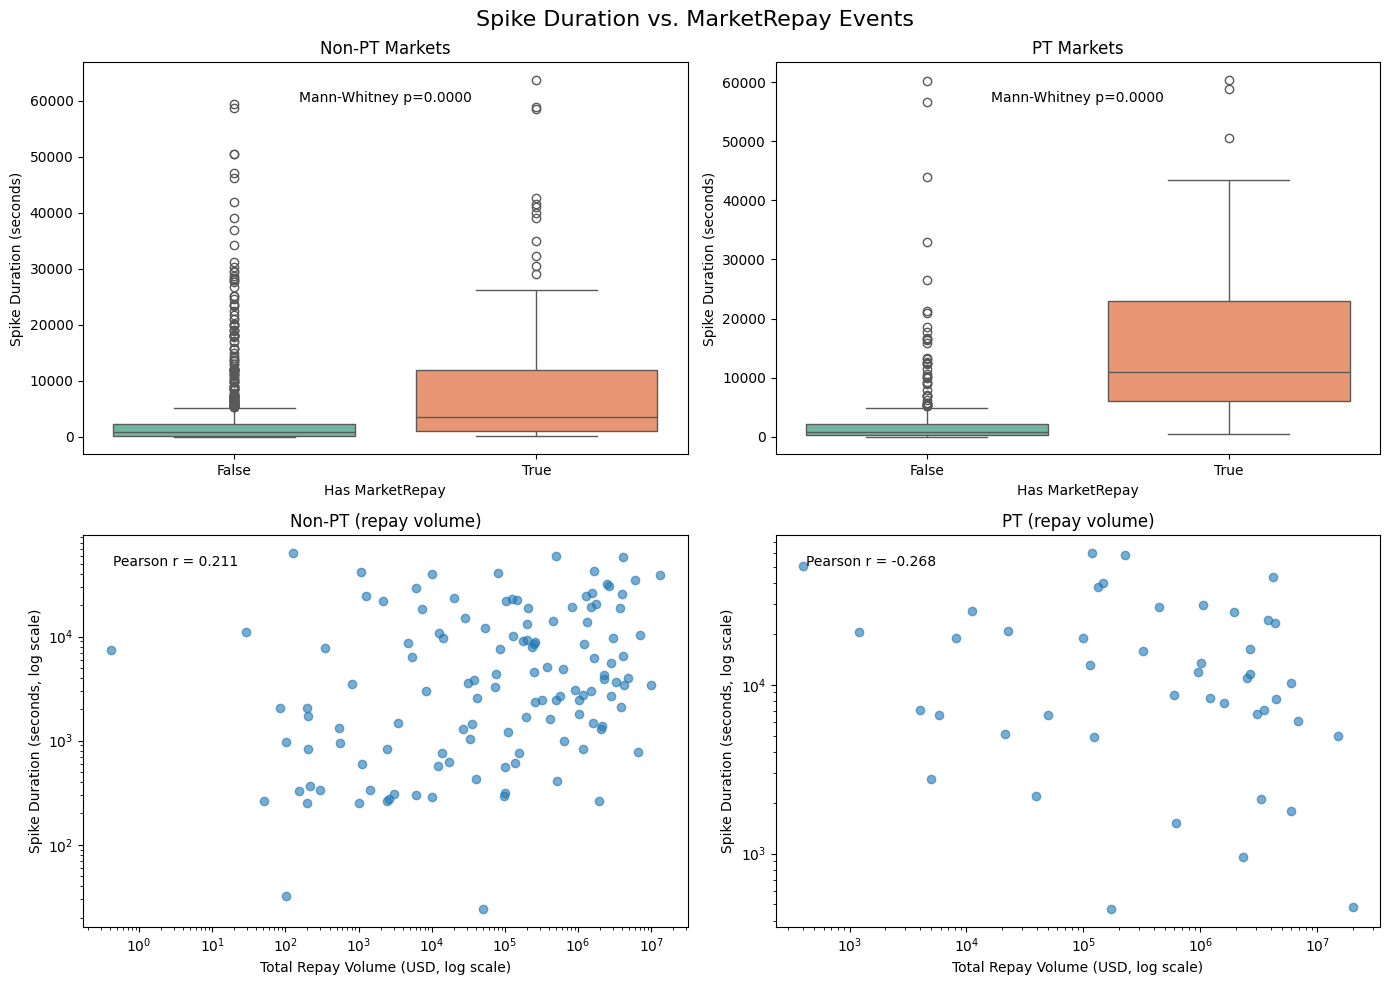


=== Summary Statistics ===

Non-PT markets:
Number of spikes: 1058
Spikes with repays: 126 (11.9%)
Spikes without repays: 932 (88.1%)
Median duration with repays: 3456 seconds
Median duration without repays: 852 seconds

PT markets:
Number of spikes: 334
Spikes with repays: 45 (13.5%)
Spikes without repays: 289 (86.5%)
Median duration with repays: 10980 seconds
Median duration without repays: 756 seconds


,market,is_pt,duration_sec,has_repay,repay_volume,spike_magnitude
0,base_cbbtc_usdc_full,False,310,False,0.000000,0.068687
1,base_cbbtc_usdc_full,False,262,True,2450.003393,0.080732
2,base_cbbtc_usdc_full,False,628,True,17047.609608,0.065669
3,base_cbbtc_usdc_full,False,250,True,198.000000,0.064573
4,base_cbbtc_usdc_full,False,336,True,1435.000000,0.065063
...,...,...,...,...,...,...
1416,eth_PT-stcUSD-23JUL2026_usdc,True,264,False,0.000000,0.135444
1417,eth_PT-stcUSD-23JUL2026_usdc,True,168,False,0.000000,0.069014
1418,eth_PT-stcUSD-23JUL2026_usdc,True,336,False,0.000000,0.066984
1419,eth_PT-stcUSD-23JUL2026_usdc,True,300,False,0.000000,0.086649


In [305]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

def analyze_spike_duration_vs_repays(all_markets_data, output_dir=None):
    """
    Analyzes spike duration vs. presence and volume of MarketRepay events.
    Separates PT and non-PT markets.
    
    Parameters:
    all_markets_data: list of dicts as returned by process_all_markets()
    output_dir: optional directory to save plots; if None, plots are displayed.
    """
    # Collect data per spike
    records = []
    for market_data in all_markets_data:
        market_name = market_data['market']
        is_pt = 'PT' in market_name
        for spike in market_data.get('spikes', []):
            duration = spike.get('recovery_time_seconds')
            if duration is None or duration <= 0:
                continue  # skip spikes without recovery
            actions_df = spike['actions_df']
            repay_mask = actions_df['type'] == 'MarketRepay'
            has_repay = repay_mask.any()
            if has_repay:
                # Total repay volume: sum of absolute changes in debt (or assets_usd)
                repay_volume = 0
                for _, row in actions_df[repay_mask].iterrows():
                    if 'debt_after' in row and 'debt_before' in row:
                        vol = abs(row['debt_after'] - row['debt_before'])
                    elif 'assets_usd' in row:
                        vol = abs(row['assets_usd'])
                    else:
                        vol = 0
                    repay_volume += vol
            else:
                repay_volume = 0
            
            records.append({
                'market': market_name,
                'is_pt': is_pt,
                'duration_sec': duration,
                'has_repay': has_repay,
                'repay_volume': repay_volume,
                'spike_magnitude': list(spike['spike_magnitudes'].values())[0] if spike['spike_magnitudes'] else np.nan
            })
    
    df = pd.DataFrame(records)
    if df.empty:
        print("No valid spikes with duration found.")
        return
    duration_99 = df['duration_sec'].quantile(0.98)
    df = df[df['duration_sec'] <= duration_99]

    
    # Separate PT and non-PT
    df_non_pt = df[~df['is_pt']]
    df_pt = df[df['is_pt']]
    
    # Create plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Spike Duration vs. MarketRepay Events', fontsize=16)
    
    # Helper to plot boxplot and stats for a given group
    def plot_group(ax, data, title):
        if data.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            return
        # Boxplot
        sns.boxplot(data=data, x='has_repay', y='duration_sec', ax=ax, palette='Set2')
        ax.set_title(title)
        ax.set_xlabel('Has MarketRepay')
        ax.set_ylabel('Spike Duration (seconds)')
        # Statistical test
        repay = data[data['has_repay']]['duration_sec']
        no_repay = data[~data['has_repay']]['duration_sec']
        if len(repay) > 0 and len(no_repay) > 0:
            stat, p = stats.mannwhitneyu(repay, no_repay, alternative='two-sided')
            ax.text(0.5, 0.9, f'Mann-Whitney p={p:.4f}', transform=ax.transAxes, ha='center')
        elif len(repay) > 0:
            ax.text(0.5, 0.9, 'Only spikes with repays', transform=ax.transAxes, ha='center')
        else:
            ax.text(0.5, 0.9, 'No repays in this group', transform=ax.transAxes, ha='center')
    
    plot_group(axes[0,0], df_non_pt, 'Non-PT Markets')
    plot_group(axes[0,1], df_pt, 'PT Markets')
    
    # Scatter plot: duration vs repay volume (only spikes with repays)
    for ax, data, title in zip([axes[1,0], axes[1,1]], 
                                [df_non_pt[df_non_pt['has_repay']], df_pt[df_pt['has_repay']]],
                                ['Non-PT (repay volume)', 'PT (repay volume)']):
        if data.empty:
            ax.text(0.5, 0.5, 'No spikes with repays', ha='center', va='center')
        else:
            ax.scatter(data['repay_volume'], data['duration_sec'], alpha=0.6)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel('Total Repay Volume (USD, log scale)')
            ax.set_ylabel('Spike Duration (seconds, log scale)')
            ax.set_title(title)
            # Correlation
            corr = data['repay_volume'].corr(data['duration_sec'])
            ax.text(0.05, 0.95, f'Pearson r = {corr:.3f}', transform=ax.transAxes, ha='left', va='top')
    
    plt.tight_layout()
    if output_dir:
        plt.savefig(f"{output_dir}/spike_duration_vs_repays.png", dpi=150)
        print(f"Plot saved to {output_dir}/spike_duration_vs_repays.png")
    plt.show()
    
    # Print summary statistics
    print("\n=== Summary Statistics ===")
    for group_name, data in [('Non-PT', df_non_pt), ('PT', df_pt)]:
        print(f"\n{group_name} markets:")
        print(f"Number of spikes: {len(data)}")
        if not data.empty:
            repay_spikes = data[data['has_repay']]
            no_repay_spikes = data[~data['has_repay']]
            print(f"Spikes with repays: {len(repay_spikes)} ({len(repay_spikes)/len(data)*100:.1f}%)")
            print(f"Spikes without repays: {len(no_repay_spikes)} ({len(no_repay_spikes)/len(data)*100:.1f}%)")
            if len(repay_spikes) > 0 and len(no_repay_spikes) > 0:
                median_repay = repay_spikes['duration_sec'].median()
                median_no_repay = no_repay_spikes['duration_sec'].median()
                print(f"Median duration with repays: {median_repay:.0f} seconds")
                print(f"Median duration without repays: {median_no_repay:.0f} seconds")
            elif len(repay_spikes) > 0:
                print(f"Median duration (all have repays): {repay_spikes['duration_sec'].median():.0f} seconds")
            else:
                print(f"Median duration: {data['duration_sec'].median():.0f} seconds")
    
    return df
analyze_spike_duration_vs_repays(results)

In [309]:

market_df
# df

,timestamp,datetime,total_supply,total_borrow,utilization,borrow_rate,supply_rate,volatility_1h,drawdown_1h,volatility_6h,drawdown_6h,collateral_price,loan_asset_price,avg_health_factor,borrow_rate_rolling,supply_rate_rolling,asset_price
0,1726214400,2024-09-13 08:00:00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,58047.000000
1,1726218000,2024-09-13 09:00:00,1.016478e+00,1.000000e+00,0.983789,0.041709,0.041041,0,0,0.001659,-0.002464,58132.000000,1,4.999352,0.020855,0.020521,58132.000000
2,1726221600,2024-09-13 10:00:00,1.016478e+00,1.000000e+00,0.983789,0.041709,0.041041,0,0,0.001659,-0.002464,58132.000000,1,4.999352,0.027806,0.027361,58168.000000
3,1726225200,2024-09-13 11:00:00,1.016478e+00,1.000000e+00,0.983789,0.041709,0.041041,0,0,0.001659,-0.002464,58132.000000,1,4.999352,0.031282,0.030781,58391.000000
4,1726228800,2024-09-13 12:00:00,1.016478e+00,1.000000e+00,0.983789,0.041709,0.041041,0,0,0.001659,-0.002464,58132.000000,1,4.999352,0.033367,0.032833,58154.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10542,1764165600,2025-11-26 14:00:00,1.149979e+09,9.165019e+08,0.796973,0.066338,0.052871,0,0,0.001785,0.000000,86667.824282,1,0.782869,0.066347,0.052889,86667.824282
10543,1764169200,2025-11-26 15:00:00,1.149862e+09,9.166151e+08,0.797152,0.066349,0.052892,0,0,0.002041,-0.000655,87157.502513,1,0.000000,0.066348,0.052890,87157.502513
10544,1764172800,2025-11-26 16:00:00,1.151495e+09,9.168638e+08,0.796238,0.066294,0.052787,0,0,0.003649,-0.006269,86853.140036,1,0.000000,0.066339,0.052873,86853.140036
10545,1764176400,2025-11-26 17:00:00,1.150357e+09,9.170426e+08,0.797181,0.066351,0.052895,0,0,0.003276,-0.002787,87823.329624,1,0.000000,0.066345,0.052883,87823.329624
